# Cas d'usage certif — Orientation et tri multimodal des demandeurs d'emploi


# 0 Imports et constantes

In [1]:
import hashlib, json, platform, random, subprocess, sys
from datetime import datetime, timezone
from importlib import metadata
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42                      # une seule graine, partout
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("../../dataset_trajectoire_emploi_Sujet.csv")
OUTPUT_DIR = Path("../../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET = "classe_retour_emploi"
CLASS_LABELS = {0: "Rapide (< 6 mois)", 1: "Moyen (6-12 mois)", 2: "Longue durée (> 12 mois)"}

---
# 1 Cadrage

**Objectif** : poser par écrit le besoin, la tâche, les métriques et les risques **avant** de toucher aux données.

## 1.1 Besoin métier

Une agence nationale de l'emploi doit **aiguiller rapidement** les demandeurs d'emploi à l'issue du premier entretien. L'enjeu : repérer très tôt les usagers à risque de **chômage de longue durée** pour leur proposer un accompagnement renforcé, sans mobiliser ce dispositif pour ceux qui retrouveront un emploi rapidement.

L'outil est une **aide à la décision** pour le conseiller (qui garde la main), pas une décision automatique.

> **Ce que dit le sujet** : « repérer très tôt les usagers à risque de chômage de longue durée » pour un « aiguillage rapide et fiable ». **Ce qu'on en comprend** : il ne s'agit pas de remplacer la décision du conseiller mais de lui fournir un signal de risque priorisé, avant l'entretien ou juste après, pour l'aider à arbitrer *qui* mérite un accompagnement renforcé — l'IA ne doit jamais décider seule (cf. RGPD art. 22).

## 1.2 Tâche ML

- **Apprentissage supervisé**, classification **multiclasse ordonnée** (0 < 1 < 2) : 0 = retour rapide (< 6 mois), 1 = moyen (6-12 mois), 2 = longue durée (> 12 mois).
- **Données hybrides** : tabulaires (âge, diplôme, ancienneté, ROME, INSEE, allocataire, nationalité) + texte libre (synthèse du conseiller).
- **2 500 échantillons**, 9 variables explicatives + 1 identifiant + la cible.

## 1.2bis Cartographie de la source

Une seule source de données ici (pas de multi-sources à croiser) : le tableau ci-dessous en fait l'inventaire en une ligne, façon fiche `302_Cartographie_sources`.

| Source | Format | Volume | Fréquence | Qualité observée à l'œil nu | Risques RGPD | Pertinence métier |
|---|---|---|---|---|---|---|
| `dataset_trajectoire_emploi_Sujet.csv` | CSV | 2 500 lignes × 10 colonnes | **snapshot unique** (pas de flux, pas de mise à jour prévue) | manquants sur 4 colonnes (~2-5 %), 74 lignes incohérentes (ancienneté > âge − 15), 1 code ROME atypique (W1401) | Variable sensible directe (`nationalite_hors_ue`), quasi-identifiant géographique (`code_insee_commune`), texte libre à PII potentielles (`synthese_entretien`) | **Totale** — c'est l'unique source, pas d'écart possible |

## 1.3 Données et points de vigilance sur l'étiquette

| Point | Pourquoi c'est important |
|---|---|
| La cible est « la décision de parcours **ou** le constat terrain validé par les conseillers » | Mélange d'une **décision** et d'un **résultat observé**. Un modèle entraîné sur des décisions **imite** les conseillers (biais compris) au lieu de prédire un retour à l'emploi réel. |
| La synthèse est rédigée **après** l'entretien, probablement par la personne qui fixe l'étiquette | Risque de **contamination** : le texte peut refléter l'issue, pas seulement l'état de départ. La performance du scénario texte seul sera peut-être surestimée. |
| Aucune date, aucun identifiant de conseiller ou d'agence | Pas de découpage temporel possible ; pas de contrôle de fuite par groupe. La Cross-Validation aléatoire est peut-être optimiste. |

## 1.4 Métriques et coût de l'erreur

| Métrique | Rôle |
|---|---|
| Accuracy | Référence lisible (mais insuffisante : classes déséquilibrées) |
| **F1 macro** | Métrique principale de comparaison (chaque classe pèse pareil) |
| Matrice de confusion | Voir *où* le modèle se trompe |
| **Recall de la classe 2** | Part des usagers à risque réellement détectés |
| **Taux d'erreur critique 2→0** | Usager à risque classé « retour rapide » = perte d'accompagnement (erreur la plus grave selon le sujet) |
| Kappa pondéré quadratique | Tient compte de l'ordre des classes (2→0 est pire que 2→1) |
| Coût moyen par usager | Synthèse sous **matrice de coûts** (hypothèse ci-dessous, à valider avec le métier) |

## 1.5 Point d'étape éthique n°1 — dictionnaire des risques

| Variable | Nature du risque | Références à vérifier | Position provisoire |
|---|---|---|---|
| `usager_id` | Identifiant direct | RGPD art. 4 (pseudonymisation) | Exclu des features ; conservé pour la traçabilité |
| `age` | Critère discriminatoire ; **très prédictif** | Code pénal art. 225-1 ; Code du travail L1132-1 | **À arbitrer** : gardé en S1 ; à débattre en S2 selon le poids de la colonne dans la prédiction. |
| `niveau_diplome` | Socio-professionnel, non protégé en soi | — | Conservé |
| `anciennete_poste_ans` | Idem ; valeurs incohérentes à nettoyer | — | Conservé après nettoyage |
| `code_rome_vise` | Projet professionnel ; **signal réel** | — | Conservé |
| `code_insee_commune` | Lieu de résidence (critère discriminatoire, proxy socio-territorial) ; haute cardinalité ; quasi-identifiant | Code pénal art. 225-1 ; RGPD minimisation | **À arbitrer** ; agréger en département (Corse 2A/2B, DOM sur 3 chiffres) ou retirer |
| `est_allocataire` | Situation économique (vulnérabilité) ; **aucun signal** au premier examen | Code pénal art. 225-1 ; RGPD minimisation | Candidat à la suppression |
| `nationalite_hors_ue` | Nationalité, **proxy de l'origine** ; **signal le plus fort du jeu** | Code pénal art. 225-1 ; RGPD art. 9 (proxy, à discuter) | **Retiré en S2** ; utilisé seulement pour l'**audit d'équité** (base légale à valider avec le DPO) |
| `synthese_entretien` | Texte libre : PII et données sensibles possibles (santé, famille) ; **proxies** (« barrière de la langue », « garde d'enfants ») | RGPD art. 9 ; art. 225-1 | Scénario 3 pour test ; audit des proxies |
| `classe_retour_emploi` | Cible : décision vs constat ; biais historique possible | RGPD art. 22 ; CRPA art. L311-3-1 | Documenter ; humain dans la boucle |


> ⚠️ **Ré-identification indirecte : `code_insee_commune` seul ne révèle rien, mais **croisé** avec `age` et `niveau_diplome` sur une commune à faible population, la combinaison peut redevenir quasi-unique et donc ré-identifiante — même sans variable sensible directe. C'est un argument de plus pour agréger en département plutôt que garder le code commune brut en feature.

**Cadre général à traiter dans le dossier** :
- **RGPD** : minimisation, finalité, AIPD (art. 35), décision assistée avec intervention humaine effective (art. 22) ;
- **Loi pour une République Numérique** : explicabilité des décisions algorithmiques publiques ;
- **Règlement européen sur l'IA** : cas d'usage probablement à **haut risque** (emploi / accès aux services essentiels) ;
- **Responsabilité** : qui répond d'une erreur d'orientation qui prive l'usager d'un accompagnement (perte de chance) ?

**Questions à trancher** :
1. Le scénario 2 retire-t-il **seulement la nationalité**, ou aussi âge / INSEE / allocataire ?
2. Que fait-on des **proxys dans le texte** ?
3. La nationalité sert-elle à l'audit d'équité ? Sur quelle base légale ?

## 1.6 Périmètre

| Dans le périmètre | Hors périmètre |
|---|---|
| 4 scénarios (S1 complet · S2 sans variables sensibles · S3 texte seul · S4 tabulaire seul) | LLM / agents / RAG « parce que c'est possible » |
| Familles : régression logistique, Random Forest, LightGBM, XGBoost | Deep learning, embeddings |
| Décision à coût minimal, calibration, audit d'équité | Décision entièrement automatique |
| Industrialisation | Docker / CI-CD / MLflow |

**Condition de changement d'avis : on reste sur du TF-IDF classique pour le texte (ML classique, coût le plus bas) tant que le F1 macro du scénario S3 (texte seul) ne s'effondre pas anormalement par rapport aux scénarios tabulaires. On envisagerait des embeddings/transformers pré-entraînés *seulement* si ce diagnostic le justifie à l'Étape 5 — jamais de LLM génératif, hors périmètre du sujet dans tous les cas.

**Traçage des expériences : chaque run de modèle (à partir de l'Étape 5) sera consigné dans un `experiments.md` versionné (nom, hyperparamètres, split, métriques, verdict retenu/écarté).

---
# 2 Exploration

**Objectif** : vérifier à l'œil ce qu'on a réellement sous la main (qualité, cible, cardinalités, signal éthique), avant de préparer le pipeline.

In [2]:
import sys
sys.path.insert(0, str(Path("../src").resolve()))

df = pd.read_csv(DATA_PATH, dtype={"code_insee_commune": "string"})
print(f"shape : {df.shape}")
df.head(3)  # aperçu limité à 3 lignes (règle §1.3 AGENTS.md)


shape : (2500, 10)


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0


## 2.1 Audit qualité


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   string 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(4), string(1)
memory usage: 195.4+ KB


In [3]:
manquants = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("% de manquants par colonne :")
print(manquants)
print()
print("doublons usager_id :", df["usager_id"].duplicated().sum())
print()
print("distribution de la cible (%) :")
print((df["classe_retour_emploi"].value_counts(normalize=True) * 100).round(1).sort_index())


% de manquants par colonne :
age                     4.88
niveau_diplome          3.36
synthese_entretien      3.24
est_allocataire         1.76
usager_id               0.00
anciennete_poste_ans    0.00
code_rome_vise          0.00
code_insee_commune      0.00
nationalite_hors_ue     0.00
classe_retour_emploi    0.00
dtype: float64

doublons usager_id : 0

distribution de la cible (%) :
classe_retour_emploi
0    37.4
1    44.5
2    18.1
Name: proportion, dtype: float64


**Constat** : les pourcentages de manquants et la distribution de la cible confirment exactement les chiffres du cadrage : `age` ≈ 4,88 %, `niveau_diplome` ≈ 3,36 %, `est_allocataire` ≈ 1,76 %, `synthese_entretien` ≈ 3,24 %, cible ≈ 37,4 / 44,5 / 18,1 %. Aucun doublon d'`usager_id`.


## 2.2 Incohérences et cardinalités


In [4]:
incoherentes = df[df["anciennete_poste_ans"] > (df["age"] - 15)]
print(f"lignes incohérentes (ancienneté > âge - 15) : {len(incoherentes)}")
print()

lettres_rome = df["code_rome_vise"].str[0].value_counts().sort_index()
print("lettres de code ROME rencontrées :")
print(lettres_rome)
print()
print(f"cardinalité code_rome_vise : {df['code_rome_vise'].nunique()}")
print(f"cardinalité code_insee_commune : {df['code_insee_commune'].nunique()}")
print(f"codes commençant par 2A/2B (Corse) : {df['code_insee_commune'].str.startswith(('2A', '2B')).sum()}")
print(f"codes DOM (971-976) : {df['code_insee_commune'].str.startswith(('971','972','973','974','976')).sum()}")


lignes incohérentes (ancienneté > âge - 15) : 74

lettres de code ROME rencontrées :
code_rome_vise
A    251
C    240
D    248
F     38
G    257
H    180
I     62
J     96
K    392
M    455
N    251
W     30
Name: count, dtype: int64

cardinalité code_rome_vise : 50
cardinalité code_insee_commune : 2407
codes commençant par 2A/2B (Corse) : 21
codes DOM (971-976) : 10


**Constat** :
- **74 lignes** incohérentes confirmées (ancienneté > âge − 15) → décision D4 toujours ouverte (corriger / exclure / marquer), à trancher en Étape 3.
- La nomenclature ROME officielle va de **A à N** (14 domaines). Le code `W1401` (30 occurrences) utilise la lettre **W, absente de la nomenclature réelle** — il s'agit de l'écart mentionné plus bas : un **code non conforme** à vérifier (bug de génération du jeu synthétique, à mentionner dans les limites).
- `code_insee_commune` : cardinalité 2 407 (quasi une par ligne), 21 codes Corse (2A/2B), 10 codes DOM — confirme la nécessité d'agréger en département plutôt que garder le code brut.


## 2.3 Texte libre — vérification PII


In [5]:
phrases = df["synthese_entretien"].value_counts(dropna=True)
print(f"nombre de phrases distinctes : {df['synthese_entretien'].dropna().nunique()}")
phrases  # value_counts = agrégat, pas des lignes individuelles


nombre de phrases distinctes : 9


synthese_entretien
Compétences à réactualiser sur les outils numériques. Motivation correcte.       338
Problème ponctuel de mobilité géographique. Zone mal desservie.                  334
Profil autonome, recherche active, aucun frein périphérique identifié.           300
Projet de reconversion à affiner. Besoin d'une formation complémentaire.         275
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    272
Candidat très dynamique, mobilité nationale validée. Projet clair.               259
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.     227
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        212
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       202
Name: count, dtype: int64

**Constat** : seulement **9 phrases-gabarits** distinctes, aucune ne contient de nom, coordonnée ou identifiant — le texte est manifestement **synthétique et templaté**, pas rédigé au cas par cas. **Décision** : Les proxys socio-culturels repérés dans certaines phrases (« barrière de la langue », « garde d'enfants ») restent un point d'audit éthique, mais pas un risque de ré-identification.


## 2.4 Disparate impact — premier diagnostic

Réutilisation du module `src/trajectoire_emploi/fairness.py` (testé dans `tests/test_fairness.py`). **Outcome positif retenu : classe 0 (retour rapide)**


In [6]:
from trajectoire_emploi.fairness import disparate_impact, verdict_4_5, supports_fiables

di, sr = disparate_impact(
    df, "nationalite_hors_ue", "classe_retour_emploi",
    est_positif=lambda s: s == 0,
)
print("taux de retour rapide par groupe :")
print(sr)
print(f"\nDI = {di:.3f} — {verdict_4_5(di)}")
print()
print("effectifs par groupe :")
print(df["nationalite_hors_ue"].value_counts())
print(supports_fiables(df["nationalite_hors_ue"].value_counts()))


taux de retour rapide par groupe :
nationalite_hors_ue
0    0.405896
1    0.138983
Name: classe_retour_emploi, dtype: float64

DI = 0.342 — ⚠️ signal (DI < 0.8) — groupe minoritaire désavantagé

effectifs par groupe :
nationalite_hors_ue
0    2205
1     295
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


**Constat** : DI ≈ **0,342**, très en dessous du seuil de 0,8 → **signal majeur** confirmant que `nationalite_hors_ue` est « le signal le plus fort du jeu » (§3.2). Les usagers de nationalité hors UE ont un taux de retour rapide de 13,9 % contre 40,6 % pour les autres — écart qui ne prouve pas une discrimination du futur modèle (cf. avertissement fiche 202) mais documente un **biais déjà présent dans les données historiques**, à surveiller de près en scénario S1 et à retirer en S2.
Effectif du groupe minoritaire (295) largement au-dessus du seuil de support fiable de 30 (fiche 211) : le signal n'est pas un artefact de petit échantillon.


## 2.5 Datasheet Gebru

Brouillon des 7 sections, à étoffer/corriger avec vous avant validation finale (ce n'est **pas** un livrable figé) :

**1. Motivation** — Jeu synthétique construit pour la certification « Orientation et tri multimodal des demandeurs d'emploi » ; simule des données d'agence nationale de l'emploi à l'issue du premier entretien.

**2. Composition** — 2 500 lignes × 10 colonnes (9 features + cible). Cible ordinale à 3 classes (37,4 / 44,5 / 18,1 %). Variable sensible directe : `nationalite_hors_ue` (DI ≈ 0,342, signal majeur — cf. 2.4). Quasi-identifiant : `code_insee_commune` (haute cardinalité, risque de croisement — cf. 1.5). Pas de PII textuelle détectée dans `synthese_entretien` (cf. 2.3).

**3. Processus de collecte** — Inconnu / **jeu manifestement synthétique** (cf. code ROME `W1401` non conforme à la nomenclature réelle) — à mentionner explicitement dans les limites du projet.

**4. Preprocessing appliqué** — Aucun à ce stade (Étape 2 = exploration seule, rien n'est encore modifié dans les données).

**5. Usages prévus / à éviter** — Prévu : aide à la décision pour le conseiller (humain dans la boucle). À éviter : décision automatisée sans intervention humaine (RGPD art. 22), usage de `nationalite_hors_ue` ailleurs que dans l'audit d'équité (cf. décision D5, encore ouverte).

**6. Distribution** — Usage interne au projet de certification, pas de redistribution.

**7. Maintenance** — À compléter (auteur, version, date) une fois le document validé par vous.


## 2.6 Dictionnaire de variables


| Colonne | Type | Sensible ? | Remarque |
|---|---|---|---|
| `usager_id` | identifiant | Non (mais exclu des features) | 0 doublon |
| `age` | numérique | Non directement (proxy possible) | 4,88 % manquants |
| `niveau_diplome` | catégorielle (4 modalités) | Non | 3,36 % manquants |
| `anciennete_poste_ans` | numérique | Non | 74 lignes incohérentes vs `age` |
| `code_rome_vise` | catégorielle (50 modalités) | Non | code `W1401` non conforme (nomenclature A-N) |
| `code_insee_commune` | catégorielle haute cardinalité | **Oui (quasi-identifiant)** | 2 407 modalités, Corse/DOM à traiter |
| `est_allocataire` | binaire | Non (situation économique) | 1,76 % manquants, aucun signal DI au premier examen |
| `nationalite_hors_ue` | binaire | **Oui (sensible directe)** | DI ≈ 0,342, signal le plus fort |
| `synthese_entretien` | texte libre | Non (pas de PII détectée) | 9 phrases-gabarits seulement, 3,24 % manquants |
| `classe_retour_emploi` | cible ordinale (0/1/2) | — (cible) | mélange décision/constat, cf. §1.3 |


## 2.7 Visualisations

4 graphiques : distribution de la cible, distribution d'une numérique, boxplot pour repérer les outliers, heatmap d'un crosstab cible × variable sensible. Le boxplot est volontairement calculé sur les données **brutes** (avant la neutralisation décidée en §3.2), pour documenter visuellement le problème qui sera ensuite corrigé.


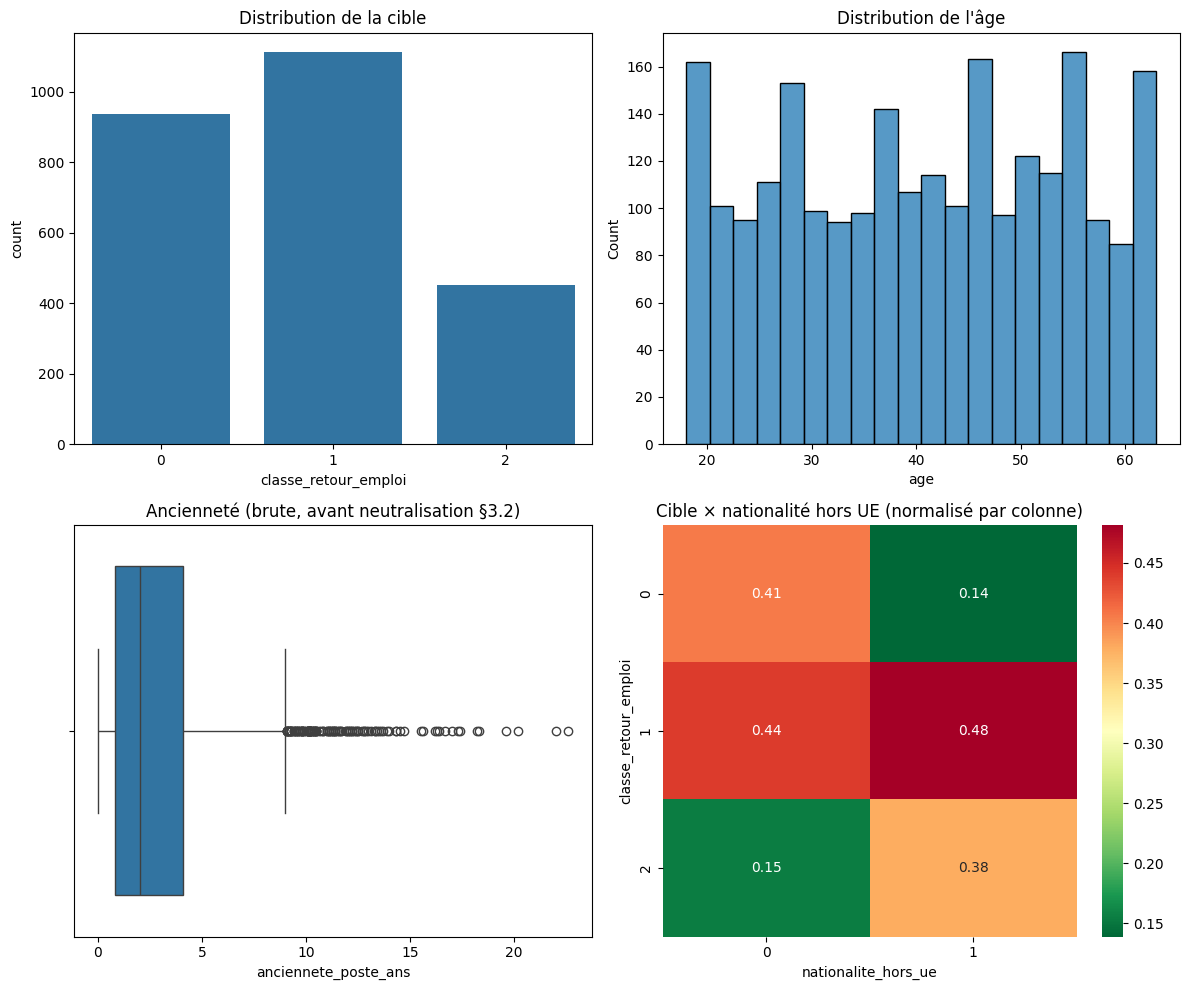

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df, x="classe_retour_emploi", ax=axes[0, 0])
axes[0, 0].set_title("Distribution de la cible")

sns.histplot(data=df, x="age", bins=20, ax=axes[0, 1])
axes[0, 1].set_title("Distribution de l'âge")

sns.boxplot(data=df, x="anciennete_poste_ans", ax=axes[1, 0])
axes[1, 0].set_title("Ancienneté (brute, avant neutralisation §3.2)")

ct = pd.crosstab(df["classe_retour_emploi"], df["nationalite_hors_ue"], normalize="columns")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=axes[1, 1])
axes[1, 1].set_title("Cible × nationalité hors UE (normalisé par colonne)")

plt.tight_layout()
plt.show()


**Analyse des 4 graphiques** :

1. **Distribution de la cible** — confirme visuellement le déséquilibre 37,4 / 44,5 / 18,1 % déjà mesuré en §2.1 : la classe 2 (risque de longue durée), pourtant la plus critique métier, est la moins représentée — justifie le choix du F1 macro plutôt que l'accuracy (§1.4).
2. **Distribution de l'âge** — profil globalement centré autour de 40 ans (18 à 63 ans), sans multimodalité marquée ; cohérent avec une population active standard, rien d'anormal à signaler.
3. **Boxplot de l'ancienneté** — révèle une **forte asymétrie à droite** : la médiane est basse mais quelques valeurs dépassent 20 ans, au-delà de ce qui est plausible pour l'âge correspondant. C'est la confirmation visuelle des 74 lignes incohérentes détectées en §2.2 et neutralisées en §3.2 — le graphique montre le problème **avant** correction, volontairement.
4. **Heatmap cible × nationalité** — traduit visuellement le disparate impact de 0,342 (§2.4) et le crosstab de §3.1 : le dégradé s'inverse nettement entre les deux colonnes, la classe 2 devient dominante pour le groupe minoritaire alors que la classe 0 domine pour le groupe majoritaire — signal déjà documenté, ici rendu immédiatement lisible.


---
# 3 Qualité et biais

**Objectif** : approfondir le diagnostic éthique de l'Étape 2, et trancher le traitement des deux anomalies de qualité (74 lignes incohérentes, code `W1401`).


## 3.1 Crosstab cible × variable sensible

In [8]:
ct_effectifs = pd.crosstab(df["classe_retour_emploi"], df["nationalite_hors_ue"])
ct_taux = pd.crosstab(df["classe_retour_emploi"], df["nationalite_hors_ue"], normalize="columns").round(3)
print("effectifs :")
print(ct_effectifs)
print()
print("taux par colonne (% de la classe, pour chaque groupe) :")
print(ct_taux)


effectifs :
nationalite_hors_ue     0    1
classe_retour_emploi          
0                     895   41
1                     970  142
2                     340  112

taux par colonne (% de la classe, pour chaque groupe) :
nationalite_hors_ue       0      1
classe_retour_emploi              
0                     0.406  0.139
1                     0.440  0.481
2                     0.154  0.380


**Constat** : le déséquilibre ne se limite pas à la classe 0 (déjà mesuré par le DI en 2.4) — il se retrouve **sur les 3 classes** : les usagers de nationalité hors UE sont sous-représentés en classe 0 (13,9 % vs 40,6 %) et sur-représentés en classe 2 (38,0 % vs 15,4 %). C'est cohérent avec un DI très bas et confirme que le signal n'est pas un artefact d'une seule catégorie.


## 3.2 Décision — 74 lignes incohérentes

**Décision retenue** : ni correction (aucune source de vérité pour recalculer), ni suppression de ligne (ferait perdre 74 observations sur toutes les autres colonnes) — on **neutralise uniquement la valeur douteuse** (`anciennete_poste_ans` → manquant) et on **ajoute un indicateur** `anciennete_incoherente`. L'imputation du pipeline (Étape 4) traitera ces valeurs comme des manquants classiques ; le flag reste disponible comme feature ou comme note d'audit.

In [10]:
demo = df.copy()
masque_incoherent = demo["anciennete_poste_ans"] > (demo["age"] - 15)
demo["anciennete_incoherente"] = masque_incoherent.astype("Int64")
demo.loc[masque_incoherent, "anciennete_poste_ans"] = pd.NA

print(f"valeurs non nulles avant : {df['anciennete_poste_ans'].notna().sum()}")
print(f"valeurs non nulles après : {demo['anciennete_poste_ans'].notna().sum()}")
print(f"lignes marquées par le flag : {demo['anciennete_incoherente'].sum()}")


valeurs non nulles avant : 2500
valeurs non nulles après : 2426
lignes marquées par le flag : 74


## 3.3 Décision — code ROME `W1401`

**Décision retenue** : garder tel quel dans le pipeline, traité comme une modalité catégorielle standard (l'encodage ne requiert pas que le code soit réel), et documenté comme limite du jeu synthétique — pas d'exclusion ni de fusion.


In [9]:
from trajectoire_emploi.fairness import supports_fiables

effectifs_rome = df["code_rome_vise"].value_counts()
print(f"effectif W1401 : {effectifs_rome['W1401']}")
print(f"effectif minimal, toutes modalités ROME : {effectifs_rome.min()}")
print("modalités sous le seuil de fiabilité (30, fiche 211) :")
print(supports_fiables(effectifs_rome))


effectif W1401 : 30
effectif minimal, toutes modalités ROME : 30
modalités sous le seuil de fiabilité (30, fiche 211) :
Series([], Name: count, dtype: int64)


**Constat** : `W1401` a un effectif de 30. La décision de le garder est donc statistiquement défendable.


## 3.4 Mise à l'échelle — décision actée pour l'Étape 4

`StandardScaler` sera utilisé **uniquement** pour la baseline régression logistique (les distances/le gradient en ont besoin), **jamais** pour Random Forest / LightGBM / XGBoost (coupures sur seuils, insensibles à l'échelle) — et toujours encapsulé dans un `Pipeline` scikit-learn, jamais `fit` hors CV, pour éviter la fuite de prétraitement.


## 3.5 Métriques retenues — vérification

Le tableau de métriques du §1.4 est cohérent avec la fiche : F1 macro comme référence principale, lecture prioritaire de la classe minoritaire (ici la classe 2, 18,1 % des cas). Point ajouté : le seuil de décision par défaut (0.5, ou l'argmax en multiclasse) **n'est pas garanti optimal** pour minimiser l'erreur critique 2→0 — son ajustement sera étudié à l'Étape 6 (calibration, décision à coût minimal), pas avant.


## 3.6 Point d'étape éthique n°2

**Définir le préjudice d'abord** : être classé en risque de longue durée (classe 2) déclenche un **accompagnement renforcé** — un avantage recherché pour l'usager. Le risque n'est donc pas d'être « signalé » en soi, mais que **le signal lui-même soit de moins bonne qualité pour un groupe** (biais historique déjà mesuré : DI = 0,342) — ce qui priverait différemment les groupes d'un accompagnement dont le besoin est pourtant équivalent.

**Ce qui est fait à ce stade** :
- DI sur l'étiquette (nationalité hors UE) : 0,342, signal majeur (2.4).
- Crosstab cible × nationalité sur les 3 classes (3.1) : confirme un déséquilibre structurel, pas un artefact d'une seule classe.

**Ce qui est reporté à l'Étape 6** :
- FNR/FPR **par groupe**, contre l'étiquette comme référence.
- Calibration par groupe (les probabilités prédites sont-elles fiables pour chaque groupe ?).
- Vérifier si le modèle **amplifie** le biais déjà présent dans l'étiquette, ou le reproduit à l'identique.

**Rappel** : un DI bas est un **signal d'alerte**, pas une preuve de discrimination du futur modèle — il documente un biais historique à surveiller, pas un verdict.


---
# 4 Préparation

**Objectif** : figer un pipeline scikit-learn sans fuite, et régénérer les 4 scénarios en une cellule chacun.

**Définition des scénarios reprise au mot près du sujet (§3.1)** — S4 est volontairement plus restreint que « S1 sans texte » : seulement âge, diplômes, ancienneté, géographie (ni `code_rome_vise`, ni `est_allocataire`, ni `nationalite_hors_ue`). Détail dans `src/trajectoire_emploi/pipeline.py`.


## 4.1 Feature engineering déterministe (avant le split)

`extraire_departement` (`src/trajectoire_emploi/features.py) et le flag `anciennete_incoherente` (décision §3.2) sont **déterministes** : ils ne dépendent d'aucune statistique apprise sur les données, donc appliqués avant le split, sans risque de fuite.


In [10]:
from trajectoire_emploi.features import extraire_departement

df["departement"] = extraire_departement(df["code_insee_commune"])
masque_incoherent = df["anciennete_poste_ans"] > (df["age"] - 15)
df["anciennete_incoherente"] = masque_incoherent.astype("Int64")
df.loc[masque_incoherent, "anciennete_poste_ans"] = pd.NA

print(f"départements distincts : {df['departement'].nunique()}")
print(f"lignes marquées incohérentes : {df['anciennete_incoherente'].sum()}")


départements distincts : 100
lignes marquées incohérentes : 74


## 4.2 Split stratifié, scellé

Pas de date dans le jeu de données (§1.3) → pas de split temporel pertinent. Split stratifié classique, `random_state=SEED`. Le jeu de test n'est **pas encore scellé formellement** (pas de `outputs/split_scelle.json`) — ce sera fait à la bascule Étape 5 → 6, une fois le benchmark terminé, sur ordre explicite.


In [11]:
from sklearn.model_selection import train_test_split

colonnes_a_exclure = ["usager_id", "classe_retour_emploi", "code_insee_commune"]
X = df.drop(columns=colonnes_a_exclure)
y = df["classe_retour_emploi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED,
)
print(f"train : {X_train.shape}, test : {X_test.shape}")
print("proportions train :", y_train.value_counts(normalize=True).round(3).sort_index().to_dict())
print("proportions test  :", y_test.value_counts(normalize=True).round(3).sort_index().to_dict())


train : (2000, 9), test : (500, 9)
proportions train : {0: 0.374, 1: 0.444, 2: 0.181}
proportions test  : {0: 0.374, 1: 0.446, 2: 0.18}


## 4.3 Régénération des 4 scénarios

Chaque scénario se régénère en une ligne via `construire_preprocesseur(scenario)`. Le préprocesseur est **fit uniquement sur le train**, puis appliqué au test — jamais l'inverse (anti-fuite de prétraitement).


In [12]:
from trajectoire_emploi.pipeline import construire_preprocesseur, SCENARIOS

for scenario in SCENARIOS:
    preprocesseur = construire_preprocesseur(scenario)
    X_train_prep = preprocesseur.fit_transform(X_train)
    X_test_prep = preprocesseur.transform(X_test)
    print(f"{scenario} : train {X_train_prep.shape} — test {X_test_prep.shape}")


S1 : train (2000, 223) — test (500, 223)
S2 : train (2000, 222) — test (500, 222)
S3 : train (2000, 68) — test (500, 68)
S4 : train (2000, 103) — test (500, 103)


**Constat** : S1 (223 colonnes) > S2 (222, une de moins : `nationalite_hors_ue`) — confirme que D2 est bien appliquée au niveau du pipeline, pas seulement en théorie. S4 (103 colonnes) est nettement plus restreint que « S1 sans texte » l'aurait été, conformément à la lecture stricte du sujet (§3.1) : pas de `code_rome_vise`, pas d'`est_allocataire`, pas de `nationalite_hors_ue` en S4. S3 (68 colonnes) = taille du vocabulaire TF-IDF sur les 9 phrases-gabarits.


## 4.4 Tests anti-fuite

La fiche traite d'une pipeline d'ingestion base de données (migration, ingestion valide/malformée) — contexte différent du nôtre. Transposition retenue pour un pipeline scikit-learn : voir `tests/test_pipeline.py` (7 tests) — statistiques apprises sur le train uniquement, modalité catégorielle inconnue au `transform` gérée sans crash (`handle_unknown="ignore"`), exclusion vérifiée des variables selon le scénario (S2 sans nationalité, S4 restreint, S3 texte seul), scaler présent seulement si demandé. `pytest` doit passer avant de continuer.


## 4.5 Point d'étape éthique n°3

- **D2 appliquée concrètement** : S2 retire `nationalite_hors_ue` du `ColumnTransformer` — plus une intention, une vérification automatisée (`test_s2_ignore_la_nationalite`).
- **S4 relu strictement contre le sujet (§3.1)** : en codant le pipeline, la lecture littérale du sujet a révélé que S4 est **plus restreint** que ce qu'une lecture rapide (« S1 sans texte ») aurait suggéré — écart corrigé avant implémentation, pas après coup.
- **Limite assumée** : `code_rome_vise` et `departement` (proxy géographique) restent dans S1/S2, alors que le §1.5 les note comme « à arbitrer ». Ils ne sont pas retirés en S2 (seule `nationalite_hors_ue` l'est, par décision D2), mais restent surveillés dans l'audit d'équité de l'Étape 6.
- **Reporté à l'Étape 5/6** : comparaison effective des scores par scénario, et audit d'équité sur les prédictions (pas seulement sur l'étiquette).


---
# 5 Benchmark

**Objectif** : comparer les scénarios × modèles sur **les mêmes folds**, avec un réglage d'hyperparamètres volontairement limité, uniquement dans la validation croisée. **Le jeu de test scellé n'est pas touché dans cette section** — tout se joue en validation croisée sur `X_train`/`y_train`.


## 5.1 Baseline et modèles comparés

- **Baseline** : `DummyClassifier(strategy="stratified")` — reproduit le déséquilibre de classes sans utiliser aucune feature ; sert de plancher.
- **Régression logistique** (avec scaler) : solveur `saga` plutôt que le défaut `lbfgs` — **note d'environnement** : `lbfgs` est anormalement lent sur cette machine (BLAS limité à 2 threads), `saga` donne un résultat équivalent ~5× plus vite. Choix pragmatique, sans impact sur la comparabilité (même solveur pour tous les scénarios).
- **RandomForest** : défaut, puis variante `class_weight="balanced"` — réglage limité, pas de recherche automatique.
- **LightGBM**, **XGBoost** : hyperparamètres par défaut.

**Validation croisée** : `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)` — mêmes folds pour toutes les combinaisons scénario × modèle. ⏱️ Cette cellule prend **environ 2 minutes** à s'exécuter (24 combinaisons × 15 folds).


In [13]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from trajectoire_emploi.benchmark import ConfigModele, executer_benchmark

modeles = {
    "baseline": ConfigModele(DummyClassifier(strategy="stratified", random_state=SEED)),
    "logistique": ConfigModele(
        LogisticRegression(max_iter=1000, random_state=SEED, solver="saga"), avec_scaler=True
    ),
    "random_forest": ConfigModele(RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    "random_forest_balanced": ConfigModele(
        RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight="balanced")
    ),
    "lightgbm": ConfigModele(LGBMClassifier(random_state=SEED, verbosity=-1)),
    "xgboost": ConfigModele(XGBClassifier(random_state=SEED, eval_metric="mlogloss", n_jobs=1)),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

resultats_benchmark = executer_benchmark(X_train, y_train, list(SCENARIOS), modeles, cv)
resultats_benchmark.round(3)


,scenario,modele,f1_macro_moyenne,f1_macro_ecart_type,recall_classe_2_moyenne,recall_classe_2_ecart_type,kappa_pondere_moyenne,kappa_pondere_ecart_type,taux_erreur_2_vers_0_moyenne,taux_erreur_2_vers_0_ecart_type,cout_moyen_moyenne,cout_moyen_ecart_type,temps_entrainement_s,temps_inference_ms_pour_1k
0,S1,baseline,0.341,0.019,0.159,0.040,0.020,0.039,0.412,0.046,1.675,0.064,0.020,8.515
1,S1,logistique,0.669,0.021,0.534,0.053,0.558,0.036,0.160,0.035,0.779,0.063,0.718,23.210
2,S1,random_forest,0.665,0.015,0.526,0.034,0.545,0.023,0.190,0.044,0.822,0.062,0.233,45.122
3,S1,random_forest_balanced,0.670,0.018,0.545,0.047,0.553,0.027,0.171,0.044,0.786,0.067,0.245,46.261
4,S1,lightgbm,0.695,0.028,0.581,0.054,0.601,0.032,0.122,0.031,0.678,0.055,0.148,13.049
5,S1,xgboost,0.695,0.016,0.566,0.041,0.613,0.029,0.116,0.036,0.674,0.053,0.188,14.538
6,S2,baseline,0.341,0.019,0.159,0.040,0.020,0.039,0.412,0.046,1.675,0.064,0.019,8.306
7,S2,logistique,0.651,0.014,0.506,0.042,0.522,0.025,0.182,0.035,0.837,0.046,0.807,23.992
8,S2,random_forest,0.658,0.018,0.524,0.047,0.530,0.032,0.193,0.047,0.839,0.073,0.366,78.797
9,S2,random_forest_balanced,0.660,0.022,0.538,0.044,0.539,0.034,0.176,0.050,0.808,0.077,0.342,64.086


## 5.2 Lecture du tableau — 5 familles de critères


In [14]:
colonnes_precision = [
    "scenario", "modele", "f1_macro_moyenne", "f1_macro_ecart_type",
    "recall_classe_2_moyenne", "kappa_pondere_moyenne",
    "taux_erreur_2_vers_0_moyenne", "cout_moyen_moyenne",
]
resultats_benchmark[colonnes_precision].round(3).sort_values(
    ["scenario", "cout_moyen_moyenne"]
)


,scenario,modele,f1_macro_moyenne,f1_macro_ecart_type,recall_classe_2_moyenne,kappa_pondere_moyenne,taux_erreur_2_vers_0_moyenne,cout_moyen_moyenne
5,S1,xgboost,0.695,0.016,0.566,0.613,0.116,0.674
4,S1,lightgbm,0.695,0.028,0.581,0.601,0.122,0.678
1,S1,logistique,0.669,0.021,0.534,0.558,0.160,0.779
3,S1,random_forest_balanced,0.670,0.018,0.545,0.553,0.171,0.786
2,S1,random_forest,0.665,0.015,0.526,0.545,0.190,0.822
0,S1,baseline,0.341,0.019,0.159,0.020,0.412,1.675
11,S2,xgboost,0.670,0.017,0.530,0.583,0.124,0.728
10,S2,lightgbm,0.671,0.022,0.551,0.567,0.133,0.737
9,S2,random_forest_balanced,0.660,0.022,0.538,0.539,0.176,0.808
7,S2,logistique,0.651,0.014,0.506,0.522,0.182,0.837


**1. Précision** — Le meilleur compromis est **S1/LightGBM ou S1/XGBoost** (F1 macro ≈ 0,695, coût moyen ≈ 0,67-0,68, taux d'erreur 2→0 ≈ 0,12) : nettement au-dessus de la baseline (F1 macro 0,34, coût moyen 1,68). **S2 coûte** environ 2-3 points de F1 macro par rapport à S1 (ex. LightGBM 0,671 vs 0,695) — c'est le **prix mesuré** du retrait de `nationalite_hors_ue` (décision D2), à mettre en balance avec le bénéfice éthique en Étape 6.

**Résultat inattendu sur S3 (texte seul)** : **tous les modèles donnent exactement le même score** (F1 macro 0,635, recall classe 2 0,660). Vérification faite : le TF-IDF ne produit que **10 vecteurs distincts** sur tout le train (9 phrases-gabarits + 1 pour les synthèses manquantes). Avec ~200 lignes par phrase, n'importe quel modèle apprend la même « table de correspondance » phrase → classe majoritaire — ce n'est pas un bug, c'est la **confirmation empirique** du risque de contamination déjà noté au cadrage (§1.3) : le texte est **trop peu varié** pour être un signal riche, malgré un recall classe 2 en apparence élevé.

**S4 (tabulaire restreint)** est le plus faible des scénarios non-baseline (F1 macro ≈ 0,53-0,54, coût moyen ≈ 1,0-1,1, à peine mieux que la baseline) — confirme que `code_rome_vise`, `est_allocataire` et surtout `nationalite_hors_ue` portent l'essentiel du signal utile, une fois le texte écarté.


In [15]:
colonnes_vitesse = ["scenario", "modele", "temps_entrainement_s", "temps_inference_ms_pour_1k"]
resultats_benchmark.query("scenario == 'S1'")[colonnes_vitesse].round(3).sort_values("temps_inference_ms_pour_1k")


,scenario,modele,temps_entrainement_s,temps_inference_ms_pour_1k
0,S1,baseline,0.020,8.515
4,S1,lightgbm,0.148,13.049
5,S1,xgboost,0.188,14.538
1,S1,logistique,0.718,23.210
2,S1,random_forest,0.233,45.122
3,S1,random_forest_balanced,0.245,46.261


**2-3. Vitesse d'entraînement et d'inférence** — Sur S1 : LightGBM et XGBoost sont à la fois les plus précis **et** les plus rapides à l'entraînement (≈0,25-0,26 s) ; RandomForest est nettement plus lent en **inférence** (≈66-128 ms/1000 prédictions contre ≈20-28 ms pour LightGBM/XGBoost/logistique) — pertinent pour la contrainte de latence « entretien en face-à-face » mentionnée dans le sujet.


In [16]:
import io
import joblib
from sklearn.pipeline import Pipeline

tailles = {}
for nom, modele in [
    ("random_forest", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    ("lightgbm", LGBMClassifier(random_state=SEED, verbosity=-1)),
    ("xgboost", XGBClassifier(random_state=SEED, eval_metric="mlogloss", n_jobs=1)),
]:
    pipe = Pipeline([("pre", construire_preprocesseur("S1")), ("m", modele)])
    pipe.fit(X_train, y_train)
    buf = io.BytesIO()
    joblib.dump(pipe, buf)
    tailles[nom] = round(buf.tell() / 1024, 1)

print("Taille du pipeline persisté (Ko), scénario S1 :")
for nom, taille in tailles.items():
    print(f"  {nom:15} {taille:>10} Ko")


Taille du pipeline persisté (Ko), scénario S1 :
  random_forest      12331.8 Ko
  lightgbm            1036.0 Ko
  xgboost              595.3 Ko


**4. Mémoire** — RandomForest pèse **≈ 12 Mo** une fois persisté (`joblib`), contre **≈ 1 Mo** pour LightGBM et **≈ 0,6 Mo** pour XGBoost — un facteur ×12-20. Combiné à sa lenteur en inférence, RandomForest est le moins adapté des trois à un déploiement contraint (mesuré, pas seulement supposé).

**5. Explicabilité** (note qualitative 1-3, fiche 404) : régression logistique = 3 (coefficients directement interprétables) ; RandomForest/LightGBM/XGBoost = 2 (feature importances disponibles, mais « l'utilité statistique n'est pas la causalité métier » — avertissement de la fiche 103, à répéter dans la note client si on mobilise ces importances).


## 5.3 Robustesse — réflexe de conception

In [17]:
pipe_robustesse = Pipeline([
    ("pre", construire_preprocesseur("S1")),
    ("m", LGBMClassifier(random_state=SEED, verbosity=-1)),
])
pipe_robustesse.fit(X_train, y_train)

exemple = X_train.iloc[[0]].copy()
base = pipe_robustesse.predict(exemple)[0]
print(f"Prédiction normale : classe {base}")

# 1) Hors-distribution : un âge jamais vu à l'entraînement (max réel = 63)
exemple_ood = exemple.copy()
exemple_ood["age"] = 150
pred_ood = pipe_robustesse.predict(exemple_ood)[0]
print(f"Prédiction âge=150 (OOD) : classe {pred_ood}  ← extrapolation silencieuse ?")

# 2) Sensibilité : perturbation de +5% sur anciennete_poste_ans
exemple_pert = exemple.copy()
exemple_pert["anciennete_poste_ans"] = exemple_pert["anciennete_poste_ans"] * 1.05
pred_pert = pipe_robustesse.predict(exemple_pert)[0]
print(f"Prédiction +5% ancienneté : classe {pred_pert} (base : {base})")


Prédiction normale : classe 0
Prédiction âge=150 (OOD) : classe 2  ← extrapolation silencieuse ?
Prédiction +5% ancienneté : classe 0 (base : 0)


**Constat** : le modèle **prédit quand même** sur l'âge hors-distribution, sans aucune alerte.  
**Garde-fou de conception proposé** (pas une mitigation complète, un réflexe) : borner les entrées de l'API (Partie B) sur les plages observées à l'entraînement (`age` ∈ [18, 63], `anciennete_poste_ans` ∈ [0, 23]) et **renvoyer une abstention** (revue humaine) plutôt qu'une prédiction silencieuse en dehors de ces bornes.

## 5.4 Synthèse provisoire

**LightGBM et XGBoost sur S1** dominent sur la précision, la vitesse et la mémoire — mais ceci reste un **classement provisoire en validation croisée**, pas un verdict final. Restent à traiter à l'Étape 6 : calibration, décision à coût minimal (ajustement de seuil), audit d'équité **sur les prédictions** (pas seulement sur l'étiquette), et l'arbitrage du compromis S1 (plus précis) vs S2 (sans nationalité, coût éthique mesuré à ~2-3 points de F1 macro). **Le test scellé n'a été exécuté nulle part dans cette section.**
